## Generating data points

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [5]:
def correctFunction(x):
    return 15 + 2.4*x - 0.5*x**2 - 0.35*x**3

In [6]:
npoints = 21
x_list = np.linspace(-5, 5, npoints)
data0 = np.array([x_list, correctFunction(x_list)])

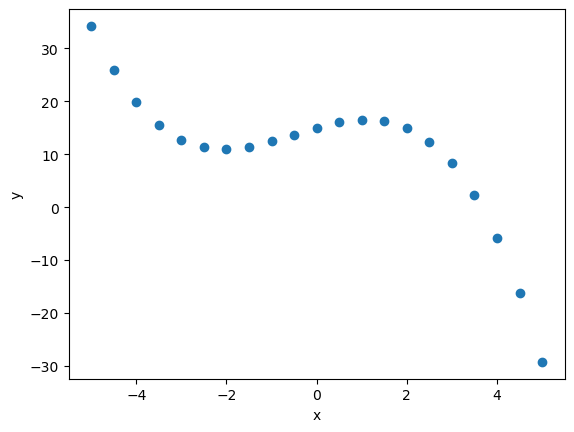

In [7]:
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(data0[0], data0[1])

In [8]:
0.1 * (2*np.random.rand(npoints) - 1)

array([-0.05366694,  0.05757063, -0.04777385,  0.09156643,  0.06913889,
        0.01243628, -0.07261396, -0.06219326,  0.0773078 , -0.06207553,
        0.09079959, -0.05406612,  0.02051744, -0.06518154,  0.07751035,
        0.04764562, -0.09372072, -0.05508493, -0.04202618,  0.08731173,
       -0.01603325])

In [9]:
data = np.array([data0[0] + 0.25 * (2*np.random.rand(npoints) - 1), data0[1] + 5.0 * (2*np.random.rand(npoints)-1)])

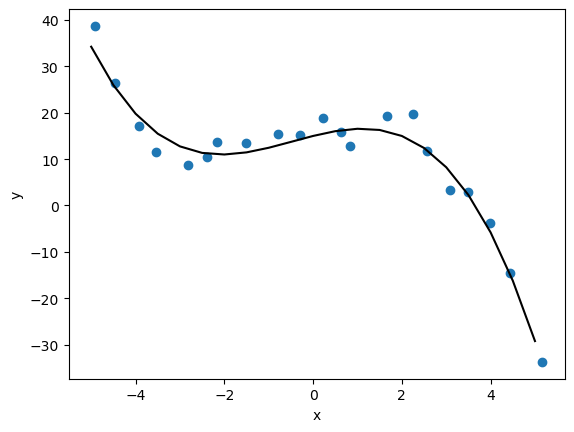

In [10]:
plt.xlabel('x')
plt.ylabel('y')

plt.plot(data0[0], data0[1], 'black')
plt.scatter(data[0], data[1])

## Generalised polynomial interpolation

In [20]:
datapoly = data[:, 0:20]

In [21]:
datapoly

array([[ -4.91254057,  -4.45727978,  -3.92094882,  -3.52974499,
         -2.82632177,  -2.3859775 ,  -2.16106141,  -1.50831381,
         -0.79365622,  -0.29969695,   0.22498021,   0.62763367,
          0.82206343,   1.65619689,   2.24740209,   2.56507521,
          3.08346743,   3.4861596 ,   3.98355717,   4.43515533],
       [ 38.73622727,  26.44213881,  17.24731541,  11.44925275,
          8.79583452,  10.43169206,  13.58770126,  13.55389178,
         15.41417666,  15.18753455,  18.94861273,  15.9282499 ,
         12.73880379,  19.28675485,  19.71938686,  11.75996577,
          3.36977222,   2.91559694,  -3.87056845, -14.61974583]])

In [22]:
def interpolation(datapoly, npoints):
    i = 0
    array = []
    while i < npoints:
        array.append(datapoly[0,:]**i)
        i = i + 1
    return np.transpose(array)

In [23]:
x = interpolation(data[:, 0:20], 20)

In [29]:
x

array([[ 1.00000000e+00, -4.91254057e+00,  2.41330549e+01,
        -1.18554611e+02,  5.82404337e+02, -2.86108493e+03,
         1.40551958e+04, -6.90467196e+04,  3.39194811e+05,
        -1.66630827e+06,  8.18580699e+06, -4.02131090e+07,
         1.97548529e+08, -9.70465164e+08,  4.76744949e+09,
        -2.34202891e+10,  1.15053120e+11, -5.65203120e+11,
         2.77658326e+12, -1.36400779e+13],
       [ 1.00000000e+00, -4.45727978e+00,  1.98673430e+01,
        -8.85543063e+01,  3.94711319e+02, -1.75933878e+03,
         7.84186516e+03, -3.49533870e+04,  1.55797025e+05,
        -6.94430930e+05,  3.09527294e+06, -1.37964975e+07,
         6.14948493e+07, -2.74099748e+08,  1.22173926e+09,
        -5.44563372e+09,  2.42727131e+10, -1.08190273e+11,
         4.82234316e+11, -2.14945327e+12],
       [ 1.00000000e+00, -3.92094882e+00,  1.53738396e+01,
        -6.02800384e+01,  2.36354945e+02, -9.26735644e+02,
         3.63368303e+03, -1.42474852e+04,  5.58636602e+04,
        -2.19038553e+05,  8.5

In [30]:
y = data[1, 0:20]

In [31]:
y

array([ 38.73622727,  26.44213881,  17.24731541,  11.44925275,
         8.79583452,  10.43169206,  13.58770126,  13.55389178,
        15.41417666,  15.18753455,  18.94861273,  15.9282499 ,
        12.73880379,  19.28675485,  19.71938686,  11.75996577,
         3.36977222,   2.91559694,  -3.87056845, -14.61974583])

In [32]:
a = np.linalg.solve(x, y)

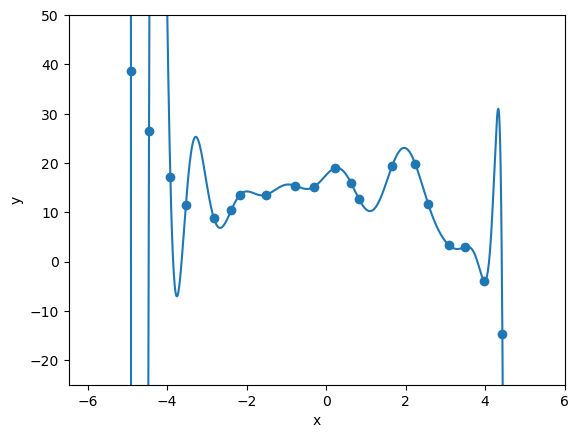

In [33]:
plt.xlabel('x')
plt.ylabel('y')
plt.ylim([-25, 50])

min_x = np.min(datapoly[0])
max_x = np.max(datapoly[0])
x_list = np.linspace(min_x-1, max_x+1, 1000)

y_list = np.zeros(len(x_list))
i = 0
while i < len(a):
    y_list = y_list + a[i]*x_list**i
    i = i + 1

plt.scatter(datapoly[0], datapoly[1])
plt.plot(x_list, y_list)